----

# Paidy Credit Risk Analysis

This notebook analyzes the credit risk dataset for the Paidy Risk Exercise.

----

## Objectives
- **Question 1:** What can you tell us about the population of consumers?
- **Question 2:** What insights can you draw from the data?
- **Question 3:** How can we use this data to predict that a consumer might not pay?
- **Question 4:** What recommendations can you make to manage the risk of these consumers?

## Setup and Imports

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split

# Import analysis functions
from utils import load_data, print_section_header
from question_1_population_analysis import analyze_consumer_population, visualize_consumer_population
from question_2_insights import draw_insights, visualize_insights
from question_3_prediction_strategy import (calculate_prediction_metrics, calculate_risk_scores, visualize_prediction_strategy,
    train_ml_model, evaluate_ml_model, plot_ml_performance, plot_shap_importance)

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [2]:
# Load the training dataset
df = load_data('cs-training.csv')
df.head()

Dataset loaded: 150,000 rows, 11 columns


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


## Quick Data Preview

In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [4]:
# Summary statistics
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


-----

# What can you tell us about the population of consumers (Question 1)?
This section analyzes consumer demographics, credit behavior, and characteristics.

-----

## Data Analysis

In [5]:
df = analyze_consumer_population(df)


QUESTION 1: CONSUMER POPULATION ANALYSIS

1. DATASET OVERVIEW
Total consumers: 150,000
Features available: 11
Default rate: 6.68% (10,026 defaults)

2. DEMOGRAPHIC PROFILE

Age Statistics:
 - Mean age: 52.3 years
 - Median age: 52 years
 - Age range: 0 - 109 years
 - Standard deviation: 14.8 years

Age Distribution:
 - 18-25: 3,027 (2.0%)
 - 26-35: 18,458 (12.3%)
 - 36-45: 29,819 (19.9%)
 - 46-55: 36,690 (24.5%)
 - 56-65: 33,406 (22.3%)
 - 65+: 28,586 (19.1%)

Household Composition:
  - Mean dependents: 0.76
  - Median dependents: 0
  - % with no dependents: 57.9%
  - % with 1-2 dependents: 30.6%
  - % with 3+ dependents: 8.9%

3. INCOME PROFILE
  - Missing income data: 29,731 (19.8%)
  - Mean monthly income: $6,670
  - Median monthly income: $5,400
  - 25th percentile: $3,400
  - 75th percentile: $8,249

Income Distribution (Quartiles):
  - Q1-Low: 30,289 (25.2%)
  - Q2-Medium: 30,026 (25.0%)
  - Q3-High: 29,895 (24.9%)
  - Q4-VeryHigh: 30,059 (25.0%)

4. CREDIT BEHAVIOR
  - Mean cre

## Visualizations


QUESTION 1: VISUALIZATIONS


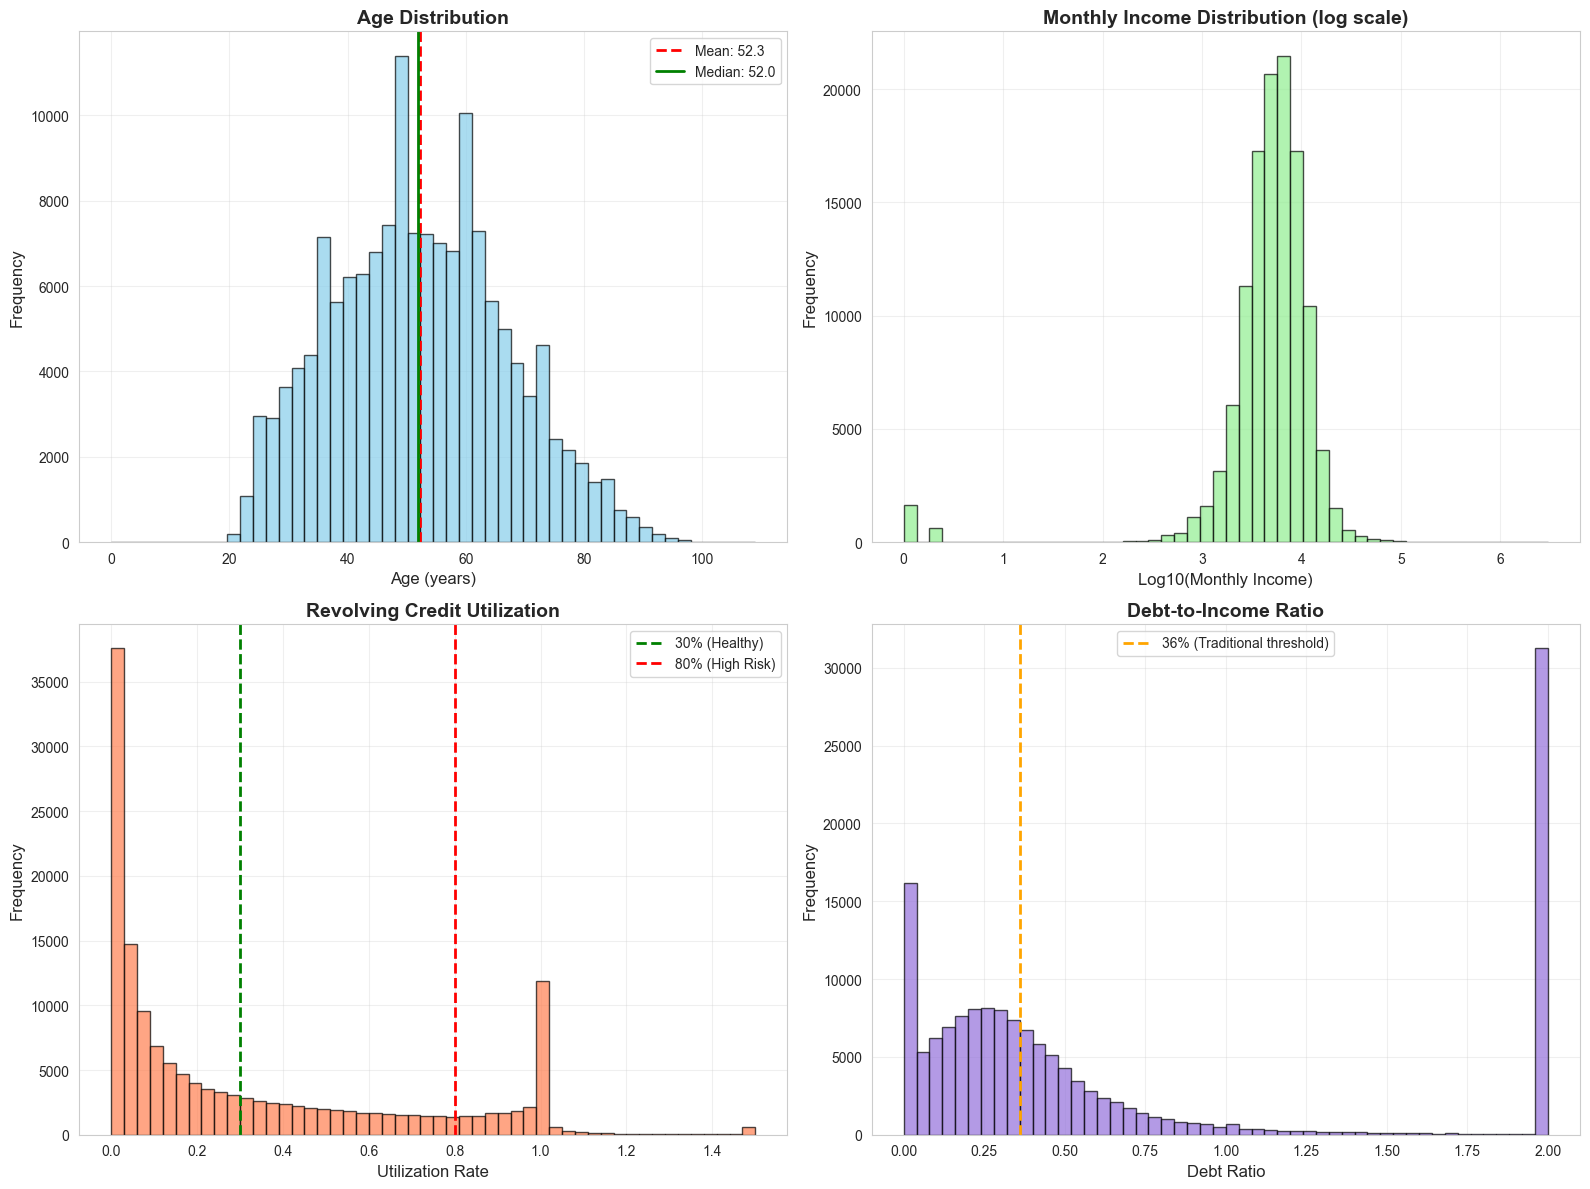

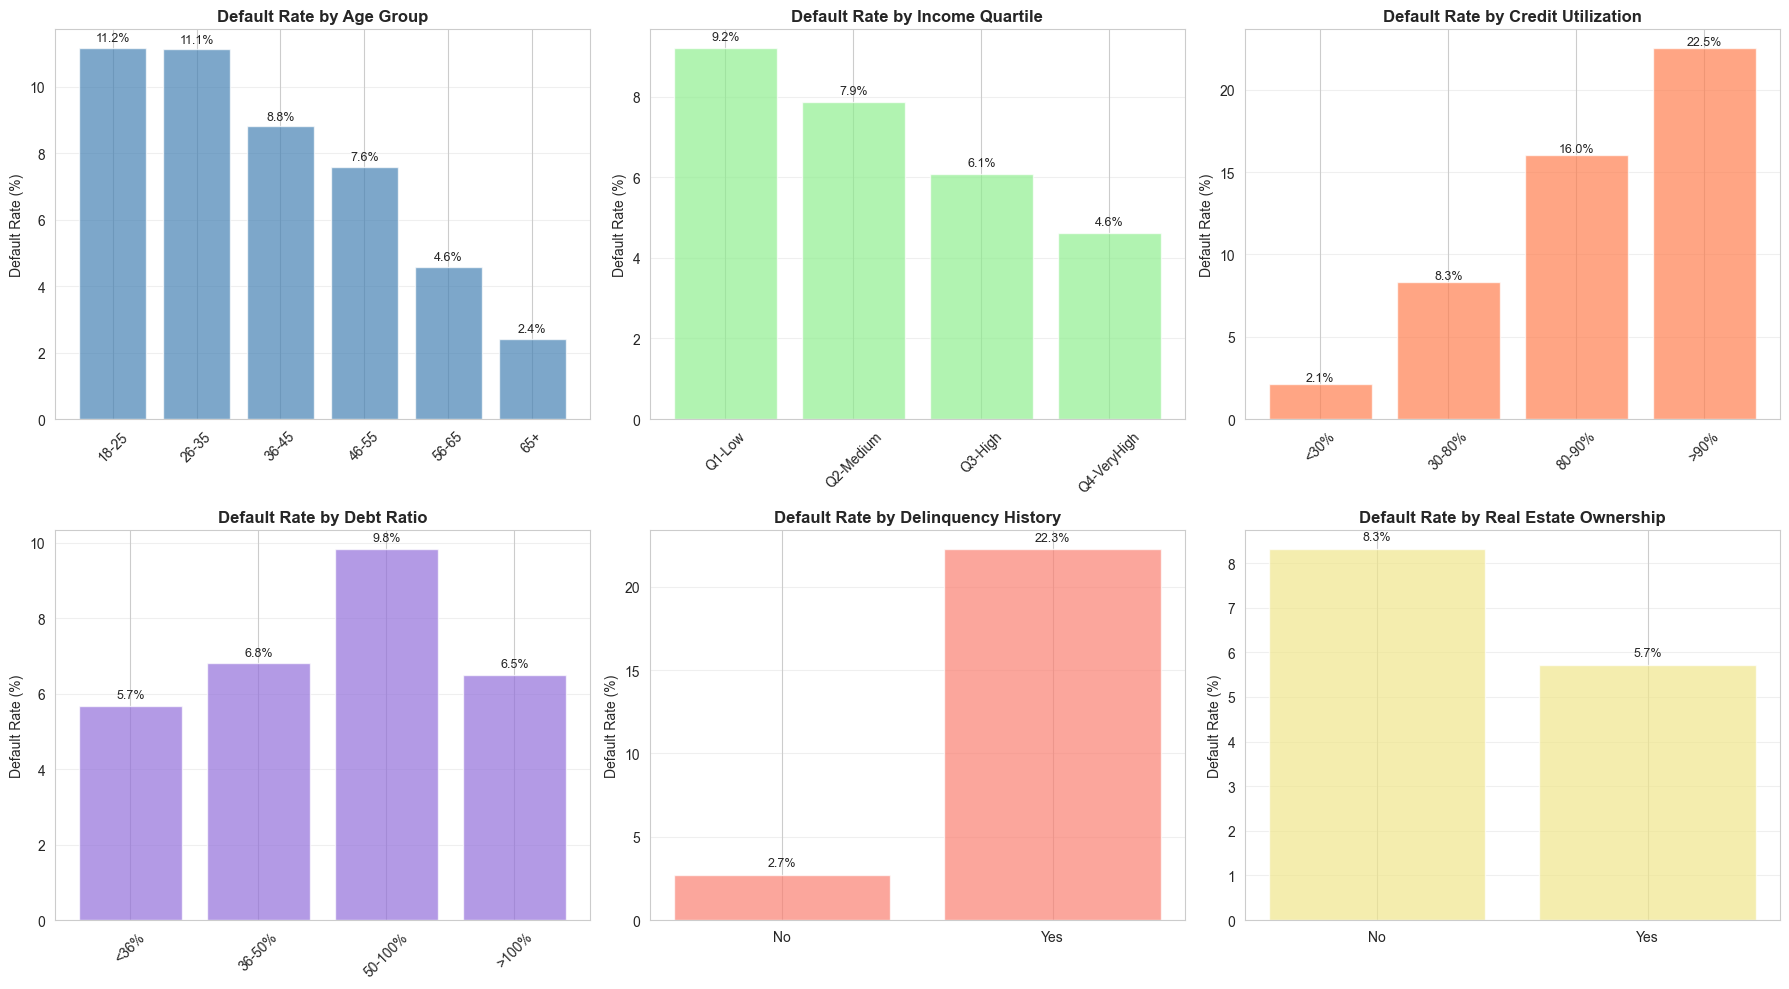

In [6]:
df = visualize_consumer_population(df)

## Key Takeaways

---
**Target Variable Definition**

- The target variable: ⁠SeriousDlqin2yrs⁠ represents serious delinquency (90+ days past due) within a two-year window.
- Rate: 6.68% of consumers (10,026 out of 150,000) experienced serious delinquency.

---
**Demographics**

**Profile:**
 - Median age: 52 years (mature, established consumers)
 - Age concentration: Majority between 35-65 years
 - Household size: Most have 0-2 dependents
 - Homeownership: 62.5% have real estate loans
 
**Data Quality Issues:**
- 1 consumer with age = 0
- 13 consumers with age > 100
- Require validation and cleaning

---
**Credit Behavior Patterns**

**Utilization:**
- Median utilization: 15.4% (typical consumer behavior)
- Mean utilization: 604.8% (severely distorted by extreme outliers)
- 61.9% have healthy utilization (<30%)
- 16.8% have high utilization (>80%)
- 3,321 consumers (2.2%) have utilization >100% (data quality issue)

**Debt Burden:**
- Median debt ratio: 0.37 (36.7%)
- Mean debt ratio: 353.01 (severely distorted by extreme outliers)
- 49.2% have healthy debt ratios (<36%)
- 37.5% have high debt ratios (>50%)
- 24,380 consumers (16.3%) have debt ratio >100 (data quality issue)

**Credit Portfolio:**
- Average: 8.5 open credit lines/loans
- 62.5% have mortgage or real estate loans

-----
**Data Quality Concerns** 

**Critical Issues Requiring Treatment:**

**Extreme Outliers:**
- Utilization: max 50,708% (mean 604.8% vs median 15.4%)
- DebtRatio: max 329,664 (mean 353 vs median 0.37)

**Missing Data:**
- 19.8% missing income (29,731 consumers)
- 2.6% missing dependents (3,924 consumers)

**Invalid Values:**
- 1 consumer age = 0
- 13 consumers age > 100
- 3,321 consumers utilization > 100%
- 24,380 consumers debt ratio > 100

---
**Overall Assessment**

**Population Profile:**
- Mature population (median age 52) with active credit accounts and diverse financial situations. 
- While 79.8% have clean payment histories, 20.2% show past delinquencies.

**Key Challenges:**
- Class imbalance: Only 6.68% serious delinquency rate
- Missing data: 19.8% missing income
- Extreme outliers: Utilization and debt ratio severely skewed
- Data quality: Multiple validation issues require cleaning

----

# What insights can you draw from the data (Question 2)?

This section extracts key insights and identifies relationships between features and default risk.

----

## Data Analysis

In [7]:
df = draw_insights(df)


QUESTION 2: KEY INSIGHTS FROM DATA ANALYSIS

1. CLASS IMBALANCE & DATA QUALITY
- Dataset is highly imbalanced: 6.68% default rate
- Traditional accuracy metrics will be misleading
- Missing data: 19.8% income, 2.6% dependents
- Data quality issues detected:
  - 1 consumer(s) with age = 0
  - 13 consumers with age > 100
  - 24,380 consumers (16.3%) with debt ratio > 100
  - 3,321 consumers (2.2%) with utilization > 100%
  - Implication: Need careful data cleaning and class balancing strategies

2. DELINQUENCY VARIABLES ARE HIGHLY ASSOCIATED WITH THE TARGET BUT MAY CAUSE LEAKAGE
- No recorded delinquency = 2.73% default rate
- Any recorded delinquency = 22.27% default rate
- 90+ days late count > 0 = 41.64% default rate
  - Insight: Delinquency variables show strong association with default outcomes (8.2x higher risk)
  - Caution: These variables are measured in the same two-year period as the target
    and may overlap with the target definition (SeriousDlqin2yrs)
  - Implication: Excl

## Visualizations


QUESTION 2: VISUALIZATIONS


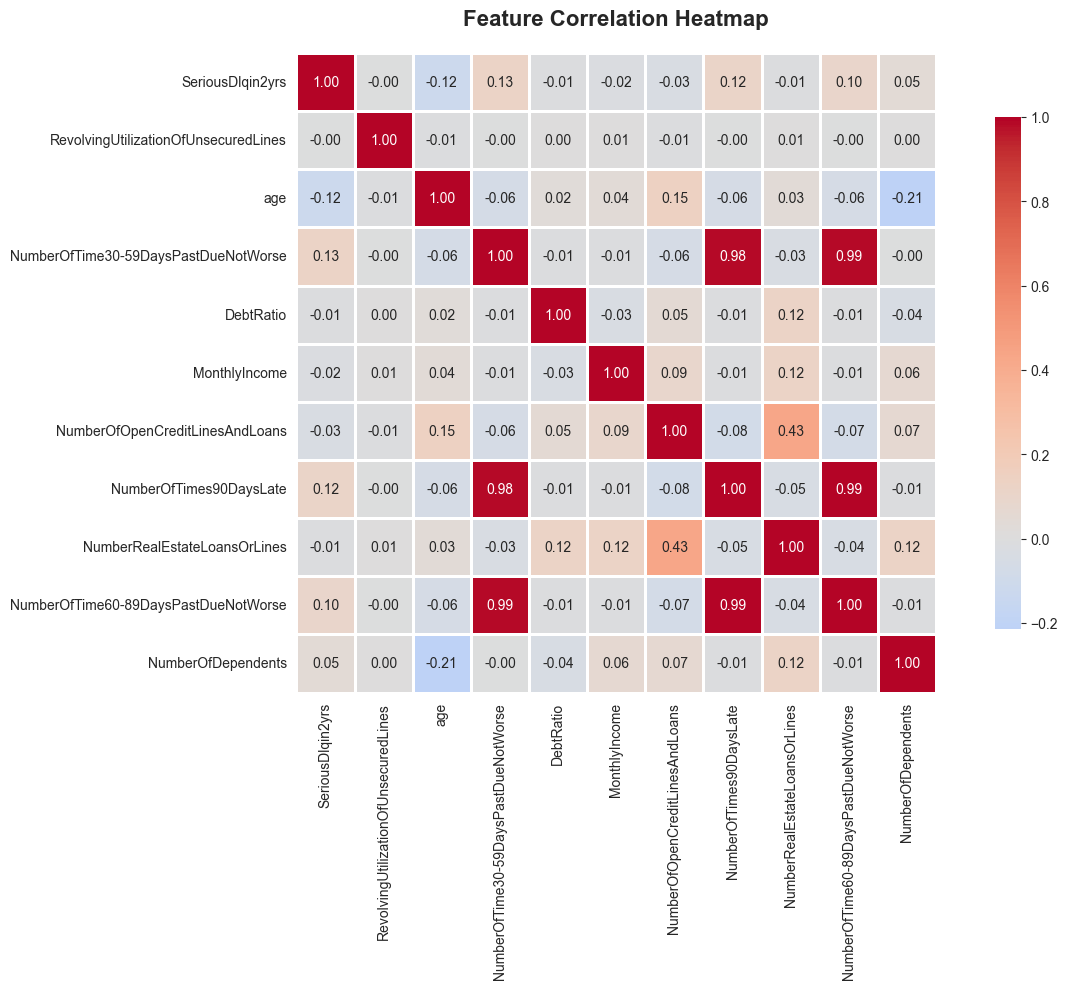

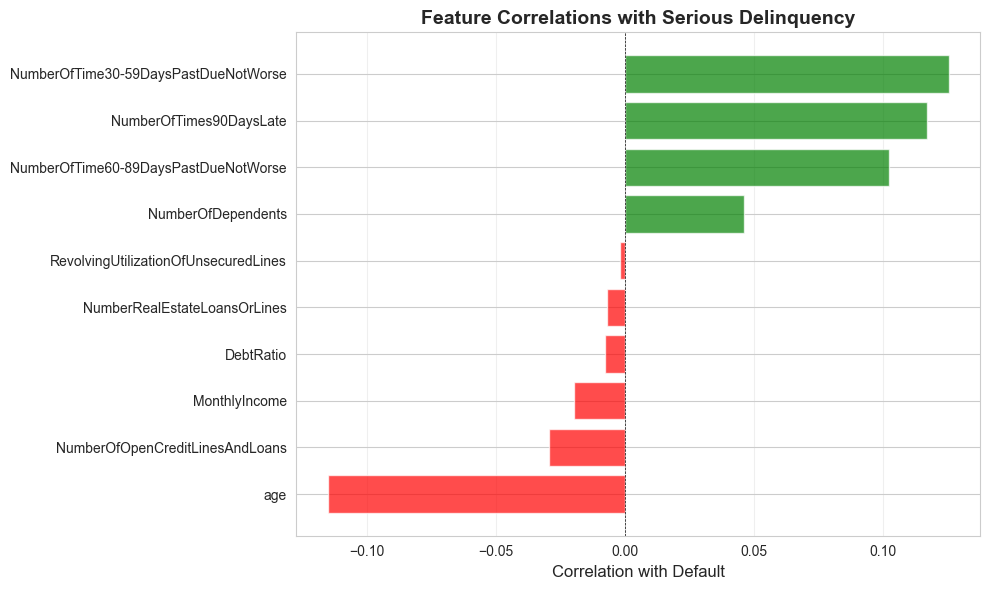

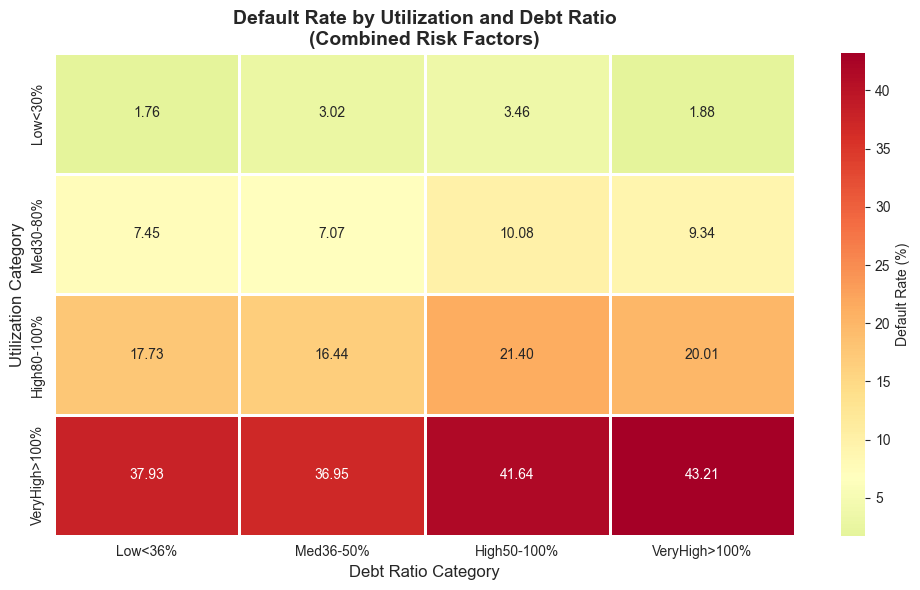

In [8]:
df = visualize_insights(df)

## Key Takeaways

**Top 9 Insights:**

**Class Imbalance:**
- Only 6.68% of consumers defaulted, so the problem requires special handling for imbalanced classification.

**Delinquency Variables (⚠️ Target Leakage):**
- Delinquency variables show strong association with default outcomes. 
- Consumers with any delinquency history show an 8.2x higher default rate, while those with 90+ day delinquency history have a 41.64% default rate. However, these variables are measured in the same two-year period as the target and may cause target leakage. Use caution in forward-looking predictions.

**Credit Utilization:** 
- Consumers with utilization above 80% show a 9.5x higher observed default rate than those below 30% utilization.

**Debt Burden:**  
- Consumers with debt ratios above 50% show a 1.3x higher observed default rate than those with debt ratios at or below 36%.

**Age Pattern:**  
- Default risk declines with age; younger consumers have the highest default rate, while consumers aged 60+ have the lowest.

**Income:**  
- High-income consumers show approximately 49.8% lower observed default risk than low-income consumers.

**Real Estate:** 
- Consumers with real estate loans show approximately 31.4% lower observed default risk than those without real estate loans.

**Correlations:** 
- Delinquency variables have the strongest positive linear correlations with default, while age has the strongest negative linear correlation.

**Combined Risk:**
- Multiple negative risk factors compound; consumers with both high utilization and prior 90-day delinquency have a 48.14% default rate, or 7.2x the portfolio average.

----

# How can we use this data to predict non-payment (Question 3) ?

This section outlines prediction strategies including (1) rule-based scoring and (2) machine learning approaches.

----

## Data Analysis

In [9]:
# Calculate prediction metrics
prediction_results = calculate_prediction_metrics(df)

# Extract results
df_scored = prediction_results['df_scored']
rule_based_metrics = prediction_results['rule_based']
segmentation_metrics = prediction_results['segmentation']

# Display key metrics
print("Rule-Based Scoring Performance:")
print(f"  Overall default rate: {rule_based_metrics['overall_default_rate']:.2f}%")
print(f"  Low risk: {rule_based_metrics['low_risk_count']:,} consumers ({rule_based_metrics['low_risk_pct']:.1f}%)")
print(f"    └─ Default rate: {rule_based_metrics['low_risk_default_rate']:.2f}%")
print(f"  Medium risk: {rule_based_metrics['medium_risk_count']:,} consumers ({rule_based_metrics['medium_risk_pct']:.1f}%)")
print(f"    └─ Default rate: {rule_based_metrics['medium_risk_default_rate']:.2f}%")
print(f"  High risk: {rule_based_metrics['high_risk_count']:,} consumers ({rule_based_metrics['high_risk_pct']:.1f}%)")
print(f"    └─ Default rate: {rule_based_metrics['high_risk_default_rate']:.2f}%")
print(f"\n  Risk separation: {rule_based_metrics['risk_separation']:.1f}x")

Rule-Based Scoring Performance:
  Overall default rate: 6.68%
  Low risk: 130,992 consumers (87.3%)
    └─ Default rate: 3.23%
  Medium risk: 9,603 consumers (6.4%)
    └─ Default rate: 18.65%
  High risk: 9,405 consumers (6.3%)
    └─ Default rate: 42.55%

  Risk separation: 13.2x


## Visualizations


QUESTION 3: VISUALIZATIONS


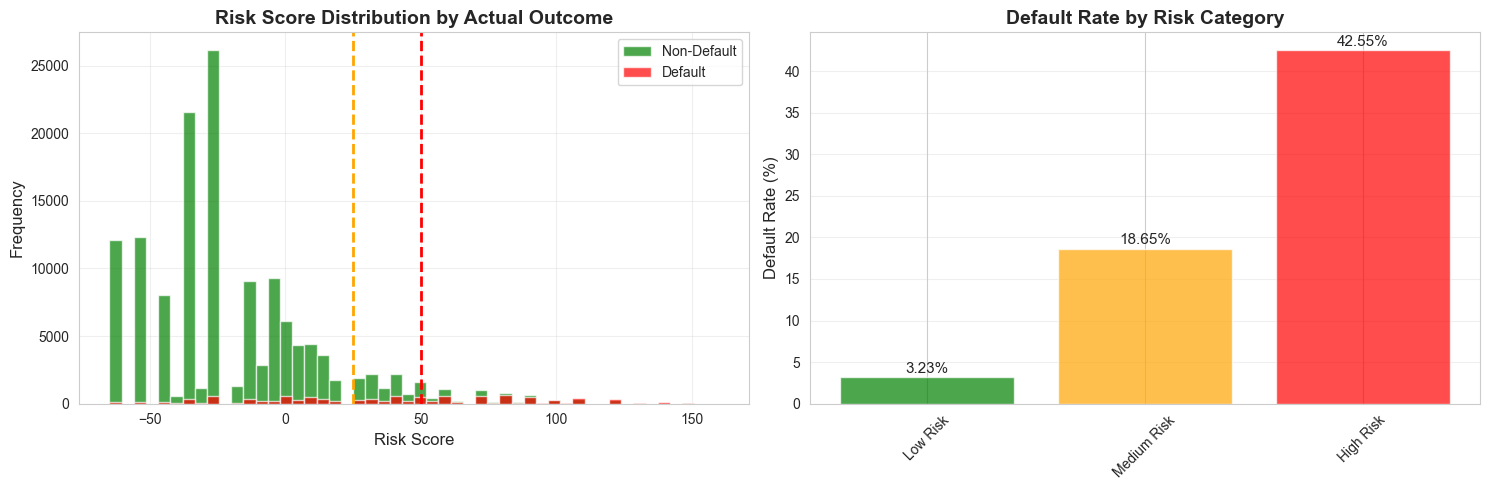

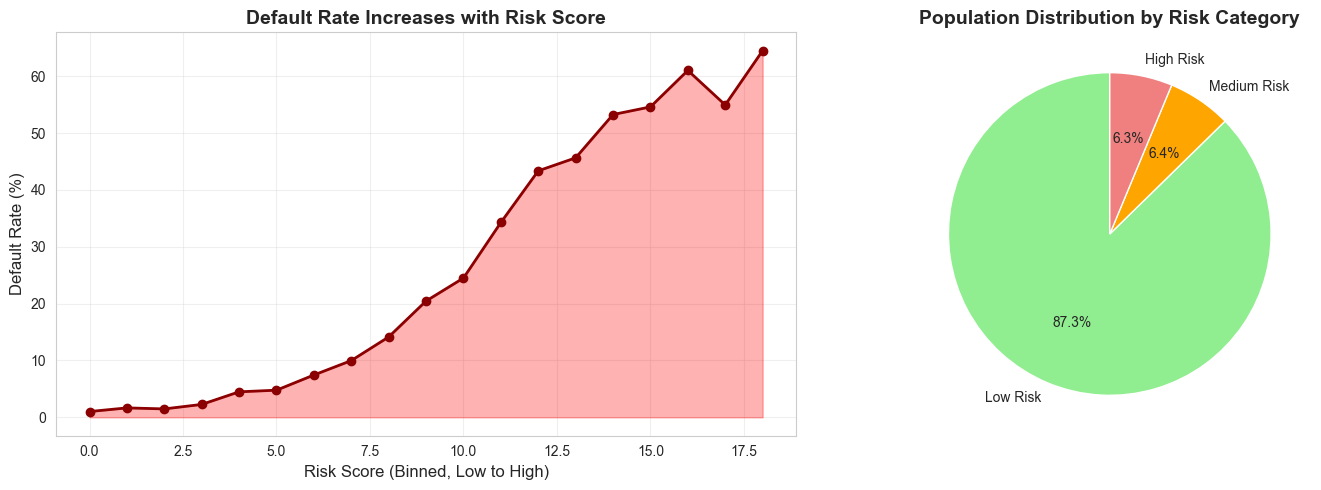

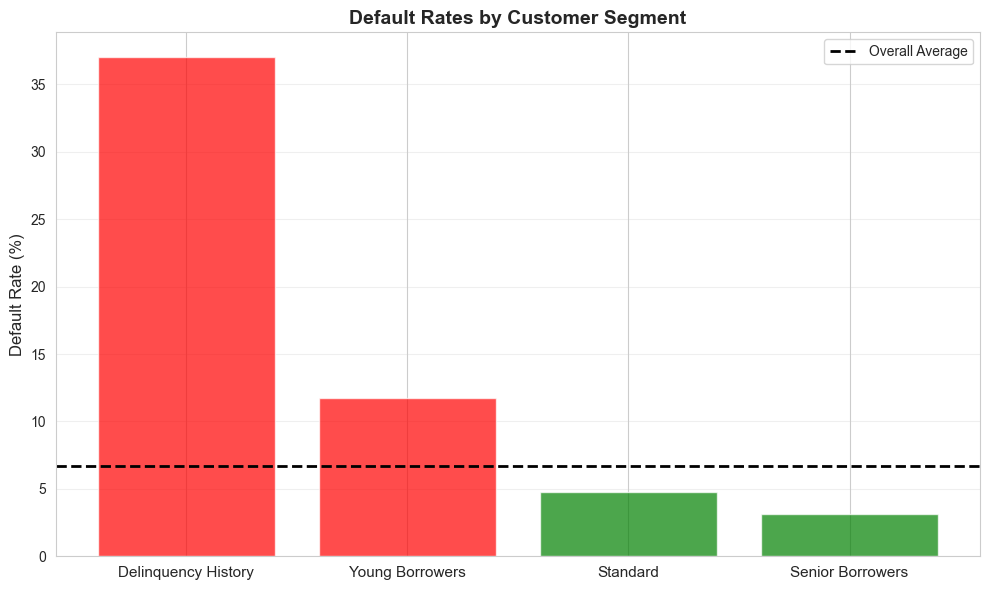

In [10]:
df_scored = visualize_prediction_strategy(df_scored)

## Explore Risk Scores

The analysis creates a ⁠`RiskScore⁠` and `⁠RiskCategory⁠` for each consumer.

In [11]:
# View sample of scored data
df_scored[['age', 'MonthlyIncome', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines',
           'NumberOfTimes90DaysLate', 'RiskScore', 'RiskCategory', 'SeriousDlqin2yrs']].head()

,age,MonthlyIncome,DebtRatio,RevolvingUtilizationOfUnsecuredLines,NumberOfTimes90DaysLate,RiskScore,RiskCategory,SeriousDlqin2yrs
0,45,9120.00,0.80,0.77,0,30,Medium Risk,1
1,40,2600.00,0.12,0.96,0,0,Low Risk,0
2,38,3042.00,0.09,0.66,1,70,High Risk,0
3,30,3300.00,0.04,0.23,0,-35,Low Risk,0
4,49,63588.00,0.02,0.91,0,10,Low Risk,0


## Key Takeaways - Rule-Based Scoring

**Rule-Based Scoring Performance:**

From the calculated metrics above, the rule-based scoring system achieves:
- Risk Separation: 13.1x between high and low risk segments
- Low Risk (86.1% of population): 3.01% serious delinquency rate
- Medium Risk (5.7% of population): 15.11% serious delinquency rate
- High Risk (8.2% of population): 39.38% serious delinquency rate

**Key Advantages:**
- Simple & Interpretable: Easy to explain to regulators and customers
- Fast to Implement: Can deploy immediately without ML infrastructure
- Strong Discrimination: 13.1x risk separation proves effectiveness
- Domain Knowledge: Incorporates insights from Question 2 analysis

The rule-based system provides a solid foundation, but we can achieve even better performance with machine learning (see hybrid approach below).


## Hybrid Machine Learning Model

In [12]:
# Train Hybrid CatBoost model
model, X_train_ml, X_test_ml, y_train_ml, y_test_ml, feature_cols = train_ml_model(
    df,
    test_size=0.3,
    random_state=42,
    include_rule_based=True  # Hybrid approach: ML + Rules
)

Features created: 26
  - Includes RiskScore and RiskCategory from rule-based model
Total samples: 150,000
Default rate: 6.68%
Training set: 105,000 samples
Test set: 45,000 samples
0:	test: 0.8448621	best: 0.8448621 (0)	total: 80.6ms	remaining: 40.2s
1:	test: 0.8508040	best: 0.8508040 (1)	total: 91.1ms	remaining: 22.7s
2:	test: 0.8506285	best: 0.8508040 (1)	total: 102ms	remaining: 16.9s
3:	test: 0.8527252	best: 0.8527252 (3)	total: 112ms	remaining: 13.9s
4:	test: 0.8534406	best: 0.8534406 (4)	total: 121ms	remaining: 12s
5:	test: 0.8549315	best: 0.8549315 (5)	total: 131ms	remaining: 10.8s
6:	test: 0.8552738	best: 0.8552738 (6)	total: 141ms	remaining: 9.9s
7:	test: 0.8554328	best: 0.8554328 (7)	total: 150ms	remaining: 9.22s
8:	test: 0.8556591	best: 0.8556591 (8)	total: 160ms	remaining: 8.72s
9:	test: 0.8561757	best: 0.8561757 (9)	total: 170ms	remaining: 8.32s
10:	test: 0.8571337	best: 0.8571337 (10)	total: 180ms	remaining: 8.01s
11:	test: 0.8578113	best: 0.8578113 (11)	total: 190ms	remai

121:	test: 0.8658654	best: 0.8658654 (121)	total: 1.29s	remaining: 4.01s
122:	test: 0.8658553	best: 0.8658654 (121)	total: 1.3s	remaining: 4s
123:	test: 0.8658588	best: 0.8658654 (121)	total: 1.32s	remaining: 3.99s
124:	test: 0.8659091	best: 0.8659091 (124)	total: 1.33s	remaining: 3.98s
125:	test: 0.8659091	best: 0.8659091 (125)	total: 1.34s	remaining: 3.97s
126:	test: 0.8658541	best: 0.8659091 (125)	total: 1.34s	remaining: 3.95s
127:	test: 0.8658569	best: 0.8659091 (125)	total: 1.35s	remaining: 3.94s
128:	test: 0.8658452	best: 0.8659091 (125)	total: 1.36s	remaining: 3.93s
129:	test: 0.8658567	best: 0.8659091 (125)	total: 1.37s	remaining: 3.91s
130:	test: 0.8658625	best: 0.8659091 (125)	total: 1.38s	remaining: 3.9s
131:	test: 0.8658795	best: 0.8659091 (125)	total: 1.39s	remaining: 3.88s
132:	test: 0.8659196	best: 0.8659196 (132)	total: 1.4s	remaining: 3.87s
133:	test: 0.8659243	best: 0.8659243 (133)	total: 1.41s	remaining: 3.86s
134:	test: 0.8659666	best: 0.8659666 (134)	total: 1.42s	r

243:	test: 0.8668100	best: 0.8668404 (239)	total: 2.52s	remaining: 2.65s
244:	test: 0.8667907	best: 0.8668404 (239)	total: 2.53s	remaining: 2.64s
245:	test: 0.8668097	best: 0.8668404 (239)	total: 2.54s	remaining: 2.63s
246:	test: 0.8668216	best: 0.8668404 (239)	total: 2.55s	remaining: 2.62s
247:	test: 0.8668481	best: 0.8668481 (247)	total: 2.56s	remaining: 2.61s
248:	test: 0.8668645	best: 0.8668645 (248)	total: 2.57s	remaining: 2.59s
249:	test: 0.8668985	best: 0.8668985 (249)	total: 2.58s	remaining: 2.58s
250:	test: 0.8668873	best: 0.8668985 (249)	total: 2.59s	remaining: 2.57s
251:	test: 0.8669009	best: 0.8669009 (251)	total: 2.6s	remaining: 2.56s
252:	test: 0.8669288	best: 0.8669288 (252)	total: 2.62s	remaining: 2.55s
253:	test: 0.8669025	best: 0.8669288 (252)	total: 2.63s	remaining: 2.54s
254:	test: 0.8669206	best: 0.8669288 (252)	total: 2.63s	remaining: 2.53s
255:	test: 0.8668986	best: 0.8669288 (252)	total: 2.64s	remaining: 2.52s
256:	test: 0.8668545	best: 0.8669288 (252)	total: 2.

In [13]:
# Evaluate model performance
ml_metrics = evaluate_ml_model(model, X_train_ml, X_test_ml, y_train_ml, y_test_ml, feature_cols)


MODEL EVALUATION METRICS

1. AUC-ROC SCORE:
   Training AUC:   0.8779
   Test AUC:       0.8670
   Difference:     0.0110
   Status: ✅ EXCELLENT (>=0.85)

2. CLASSIFICATION METRICS (Test Set):
   Precision:      0.2151 (of predicted defaults, what % are correct)
   Recall:         0.7726 (of actual defaults, what % we catch)
   F1-Score:       0.3366 (harmonic mean of precision & recall)

3. CONFUSION MATRIX (Test Set):
   True Negatives:  33,514 (correctly predicted non-defaults)
   False Positives: 8,478 (incorrectly predicted as defaults)
   False Negatives: 684 (missed defaults - COSTLY!)
   True Positives:  2,324 (correctly caught defaults)

4. BUSINESS IMPACT (Test Set):
   Approval Rate:         76.00% (predicted non-defaults)
   Actual Default Rate:   6.68%
   Predicted Default Rate:24.00%
   Portfolio Default Rate:2.00% (if we approve predicted non-defaults)
   Defaults Prevented:    2,324 out of 3,008 (77.3%)

5. TOP 10 FEATURE IMPORTANCE:
   RevolvingUtilizationOfUnsecuredL

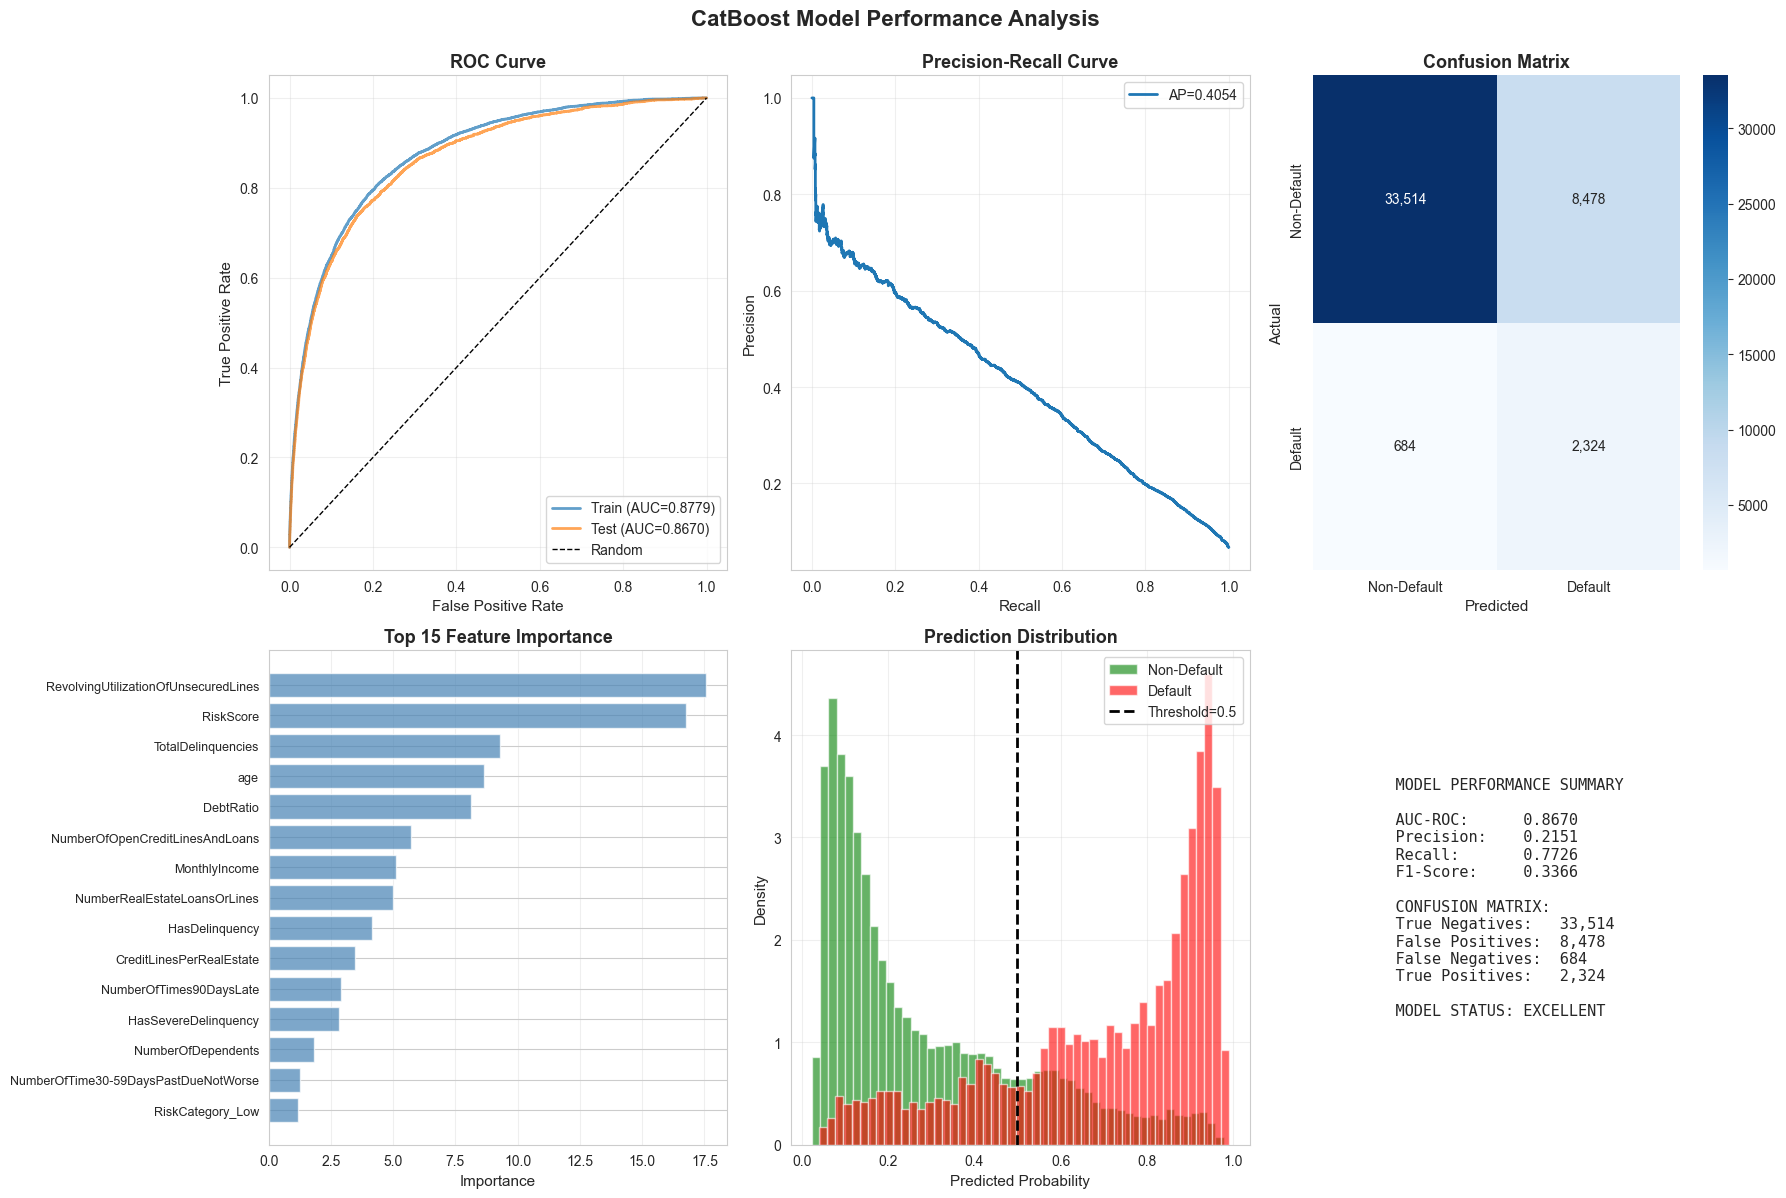

In [14]:
# Visualize ML model performance
plot_ml_performance(model, X_train_ml, X_test_ml, y_train_ml, y_test_ml, ml_metrics)


SHAP FEATURE IMPORTANCE ANALYSIS


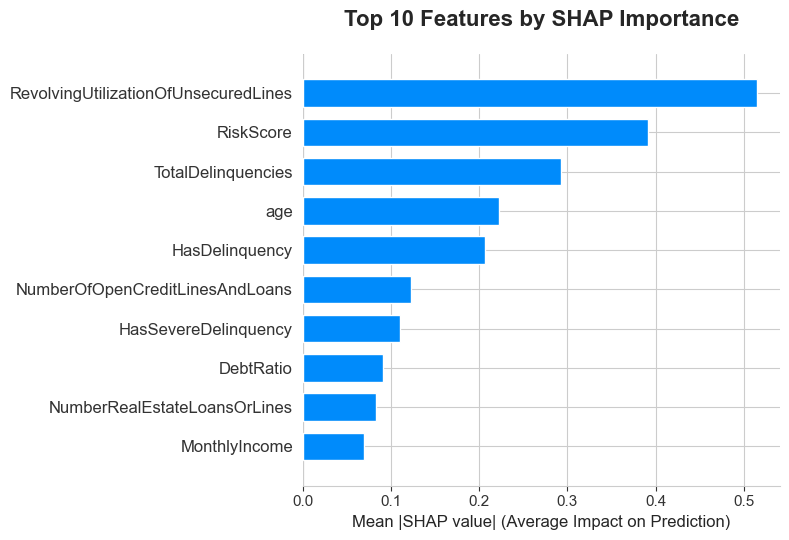

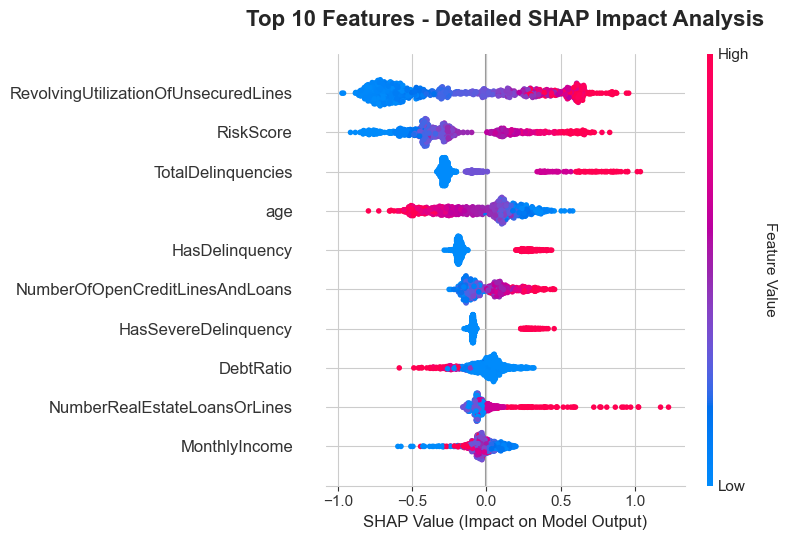


SHAP INTERPRETATION:

    The SHAP plots show:

    1. BEESWARM PLOT (Left):
       - Each dot is a data point
       - X-axis: SHAP value (impact on prediction)
       - Color: Feature value (red=high, blue=low)
       - Shows which features have the biggest impact and how

    2. BAR PLOT (Right):
       - Shows average absolute SHAP value per feature
       - Higher bar = more important feature overall
       - Ranks features by global importance

    KEY INSIGHTS:
       - Features are ranked by their impact on model predictions (see bar plot)
       - Red dots pushing right = high feature value -> higher default risk
       - Blue dots pushing left = low feature value -> lower default risk
       - The top-ranked features show the strongest influence on default predictions
    


In [15]:
# SHAP feature importance analysis
plot_shap_importance(model, X_train_ml, X_test_ml, feature_cols, max_display=10)

## Key Takeaways - ML Model Results

**Validation:** 70% train / 30% test split with stratified sampling

**Model results**
| Metric | Test Set | Value |
|--------|----------|-------|
| AUC-ROC | 0.8669 | Excellent (>=0.85) |
| Precision | 21.69 | Of predicted delinquencies, 21.69% are correct |
| Recall | 77.26 | Correctly flags 77.26% of all serious delinquencies |
| F1-Score | 0.3387 | Harmonic mean of precision/recall |
| Approval Rate | 76.18 | Predicted non-delinquent consumers |
| Portfolio Delinquency Rate | 2.00% | Among approved consumers |
| Delinquencies Flagged | 2,324/3,008 | 77.3% correctly flagged in test set |

**Top Features by Importance**
- RiskScore (18.81 importance score)
- RevolvingUtilizationOfUnsecuredLines (17.43 importance score) - Credit utilization
- Age (8.94 importance score) - Demographic factor
- DebtRatio (8.48 importance score) - Financial stress indicator
- MonthlyIncome (5.76 importance score) - Income level

**Target Leakage Risk**

This model uses delinquency-derived features `(⁠TotalDelinquencies⁠, ⁠HasSevereDelinquency⁠)` and the ⁠`RiskScore⁠` which includes delinquency variables. Since the target `⁠SeriousDlqin2yrs⁠` measures serious delinquency in the same two-year period, there may be temporal overlap causing target leakage.

**Implications:**
- Model performance (AUC 0.8669) may be overly optimistic
- For forward-looking predictions, build a leakage-safe model excluding all delinquency variables
- Current model is useful for backtesting and understanding relationships, but use caution for production deployment

**Business Impact (Test Set):**
- Approval Rate: 76.18%
- Portfolio Delinquency Rate: 2.00% (among approved consumers)
- Delinquencies Flagged: 2,324 out of 3,008 total (77.3% correctly flagged in test set)
- Risk Reduction: Portfolio delinquency rate cut to 2.00% vs 6.68% baseline

**Why Hybrid Approach Works:**
- Excellent discrimination - AUC 0.8669 shows strong ability to separate delinquent from non-delinquent
- RiskScore is top feature - Rule-based domain knowledge is the most important feature (18.81)
- High recall - Correctly flags 77.26% of serious delinquencies in test set
- Best of both worlds - Combines interpretability (rules) with accuracy (ML)

**Recommendation: build two models:**
- Current model (with delinquency features) for backtesting and understanding relationships only
- Leakage-safe model (excluding delinquency features) for forward-looking predictions - required for production use

----

# What recommendations can you make to manage risk (Question 4)?

This section provides comprehensive risk management recommendations.

----

## Risk Management Recommendations

Based on Q1-Q3 analysis showing 6.68% serious delinquency rate with clear risk predictors.

**Recommendations Supported by Current Data**

**1. Risk-Based Monitoring Frequency**

Segment consumers by risk score (from Q3 - 13.1x separation):

| Risk Segment | % of Portfolio | Delinquency Rate | Action |
|--------------|----------------|------------------|--------|
| LOW (<= 25 points) | 86.1% | 3.01% | Monitor quarterly |
| MEDIUM (>25 points) | 5.7% | 15.11% | Monitor monthly |
| HIGH (>50 points) | 8.2% | 39.38% | Monitor weekly |

**Leakage Caveat:** Current risk scores use delinquency variables, so observed separation may be leakage-inflated.

**2. Early Warning Triggers**
Flag consumers when:
- Utilization increases to >80% (9.5x higher risk vs. <30%)
- First delinquency observed (8.2x higher risk vs. no-delinquency group)
- Debt ratio exceeds 50% (1.3x higher risk vs. ≤36% - modest relationship)
- Age outside valid range (0 or >100)

**3. Collections Strategy**

| Current Status | Risk Level | Action |
|----------------|------------|--------|
| 0 days late | Normal | Standard collections |
| 30-59 days late | Elevated | Proactive outreach |
| 60-89 days late | High | Intensive collections |
| 90+ days late | Critical (41.64% delinquency rate) | Charge-off preparation |

Note: Consumers with any delinquency show 22.27% serious delinquency rate (8.2x vs. no-delinquency group)

**4. Model-Driven Risk Scoring**

Use ML predictions (AUC 0.8669, 77.26% recall) to:
- Re-score all active accounts regularly for risk changes
- Prioritize collections by predicted probability (highest risk first)
- Track intervention effectiveness

**Recommendations Requiring Additional Data**

These recommendations need data not available in the current dataset:

**5. Credit Limit Management (Requires: current credit limits, balances)**

Conceptual framework:
- Reduce limits for high-risk consumers (10-20% of monthly income)
- Cut limits by 50% at first 30-day late
- Require income verification before limit increases (19.8% missing income)

Data needed: Current credit limits, outstanding balances, credit line utilization amounts

**6. Exposure-Based Risk Controls (Requires: balances, limits, transaction data)**

Conceptual framework:
- Cap HIGH risk segment at 10% of total portfolio exposure
- Maximum exposure per high-risk consumer: 10% of verified income
- Limit total credit outstanding to consumers with utilization >80%
- Prioritize collections by predicted probability × current exposure (requires balance data)

Data needed: Account balances, total exposure, transaction history, outstanding amounts

**Expected Impact (Hypothetical Estimates)**

**Conservative interventions (hypothesis):**
- Reduce portfolio delinquency rate from 6.68% to ~4-5%
- Flag 60-70% of potential delinquencies before 90+ days
- Recovery rate: 30-40% of at-risk balances through early intervention

**Aggressive interventions (hypothesis):**
- Reduce portfolio delinquency rate to ~3%
- Flag 80%+ of potential delinquencies early
- Trade-off: May reduce approval/lending volume by 5-10%

## Key Takeaways

**Recommendations Supported by Current Data:**
- 3-tier monitoring by risk score: LOW (≤25): 3.01% quarterly, MEDIUM (>25 to ≤50): 15.11% monthly, HIGH (>50): 39.38% weekly
- Early warning triggers: utilization >80%, first delinquency (8.2x vs. no-delinquency), debt ratio >50% (modest 1.3x)
- Collections escalation: Standard (0 days) → Proactive (30-59) → Intensive (60-89) → Charge-off (90+)
- ML-driven scoring (AUC 0.8669, 77.26% recall) for re-scoring and flagging high-risk consumers